###### Problem Statement: Predicting `cardiovascular disease risk` from a single biomarker $x$ (e.g., a cholesterol-related measurement)

**The clinical truth**:
* Very low $x$ &rarr; high risk (deficiency)
* Moderate $x$ &rarr; low risk (deficiency)
* Very high $x$ &rarr; high risk (deficiency)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import warnings 
warnings.filterwarnings('ignore')

np.random.seed(42)

In [18]:
def generate_biomarker_data(n = 600):
    # Three clinical sub-populations
    low = np.random.normal(20, 5, n // 3)   # deficiency zone
    mid = np.random.normal(60, 8, n // 3)   # health zone
    high = np.random.normal(100, 5, n // 3) # toxicity zone

    X = np.concatenate([low, mid, high]).reshape(-1, 1)

    # Risk logic: middle is healthy (0), extremes are risky (1)
    # Added explicit parentheses around conditions
    flat_X = X.flatten()
    y = np.where((flat_X > 40) & (flat_X < 80), 0, 1)

    # Add a bit of label noise so it's not trivially separable
    noise_idx = np.random.choice(len(y), size = int(0.05 * len(y)), replace = False)

    y[noise_idx] = 1 - y[noise_idx]

    return X, y

X, y = generate_biomarker_data()
print(f"Dataset shape: {X.shape}, class balance: {np.bincount(y)}")


Dataset shape: (600, 1), class balance: [216 384]


In [20]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((480, 1), (120, 1), (480,), (120,))

In [21]:
# Build Two Competing Models
from sklearn.pipeline import Pipeline

# Model A: Linear Logistic Regression (no polynomial features)
linear_model = Pipeline(steps = [
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

# Model B: Polynomial Logistic Regression (degree = 2)
poly_model = Pipeline(steps = [
    ('poly', PolynomialFeatures(degree = 2)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

In [23]:
# Train Both Models
linear_model.fit(X_train, y_train)
poly_model.fit(X_train, y_train)

for name, model in [('Linear', linear_model), ('Polynomial (degree = 2)', poly_model)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:25s} | Train: {train_acc:.3f} | Test: {test_acc:.3f}")

Linear                    | Train: 0.640 | Test: 0.642
Polynomial (degree = 2)   | Train: 0.954 | Test: 0.925


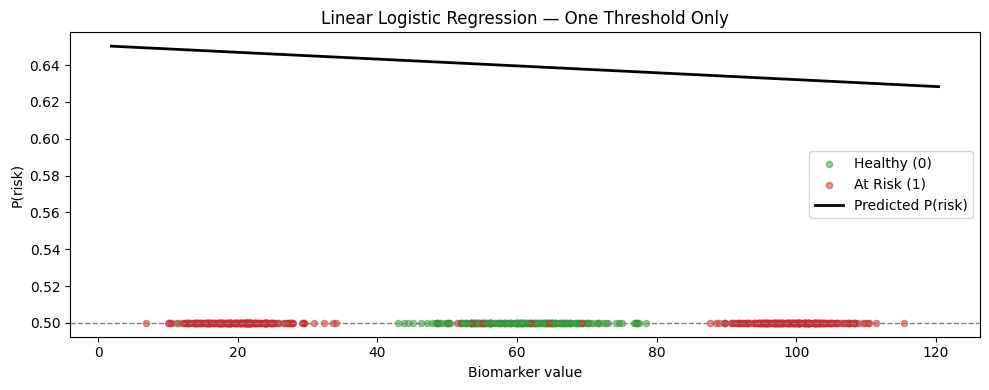

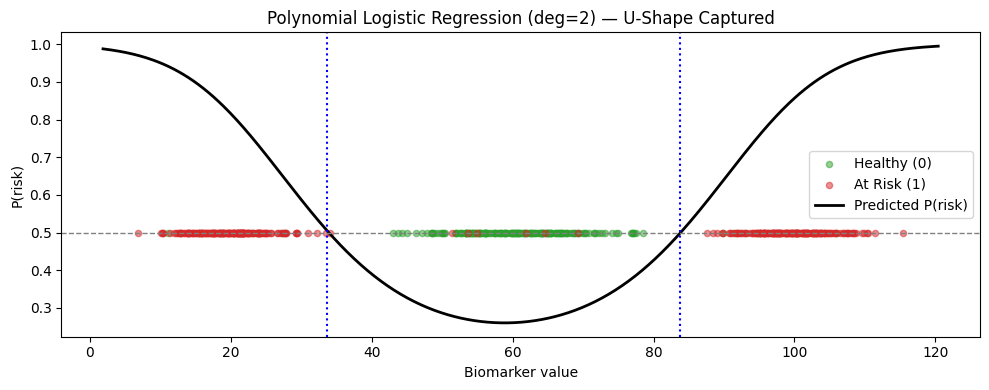

In [24]:
def plot_decision_boundary(model, X, y, title):
    # Create a dense grid of biomarker values
    x_grid = np.linspace(X.min() - 5, X.max() + 5, 500).reshape(-1, 1)
    probs = model.predict_proba(x_grid)[:, 1]

    fig, ax = plt.subplots(figsize=(10, 4))

    # Scatter patients
    ax.scatter(X[y == 0], np.zeros_like(X[y == 0]) + 0.5,
               color="tab:green", alpha=0.5, label="Healthy (0)", s=20)
    ax.scatter(X[y == 1], np.zeros_like(X[y == 1]) + 0.5,
               color="tab:red", alpha=0.5, label="At Risk (1)", s=20)

    # Plot predicted probability curve
    ax.plot(x_grid, probs, color="black", linewidth=2,
            label="Predicted P(risk)")

    # Mark the decision boundary at p = 0.5
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    crossings = x_grid.flatten()[
        np.where(np.diff((probs > 0.5).astype(int)) != 0)[0]
    ]
    for c in crossings:
        ax.axvline(c, color="blue", linestyle=":", linewidth=1.5)

    ax.set_xlabel("Biomarker value")
    ax.set_ylabel("P(risk)")
    ax.set_title(title)
    ax.legend(loc="center right")
    plt.tight_layout()
    plt.show()

plot_decision_boundary(linear_model, X, y,
                       "Linear Logistic Regression — One Threshold Only")
plot_decision_boundary(poly_model, X, y,
                       "Polynomial Logistic Regression (deg=2) — U-Shape Captured")

# 📘 Polynomial Features in Logistic Regression

## Core Idea

* Logistic Regression = linear classifier $\rightarrow$ straight decision boundary.
* Add polynomial features $\rightarrow$ curved decision boundary.
* Model stays linear in parameters; only the inputs become non-linear.

------------------------------
## Why It Works

* $z = w_1x_1 + w_2x_2 + b \rightarrow$ Line
* $z = w_1x_1 + w_2x_2 + w_3x_1^2 + w_4x_2^2 + w_5x_1x_2 + b \rightarrow$ Conic (circle, ellipse, parabola, hyperbola)
* Sigmoid still converts $z \rightarrow$ probability.

------------------------------
## Linear vs. Logistic Regression

| Feature | Linear Regression | Logistic Regression |
|---|---|---|
| Polynomial bends... | Prediction curve | Decision boundary |
| Output | Continuous | Probability / class |
| Loss | MSE | Log Loss |

------------------------------
## Real-World Use

* U-shaped medical risk (e.g., biomarker vs. disease).
* Behavioral churn (low & high usage $\rightarrow$ churn).
* Any circular or non-linear class separation.

------------------------------
## Analogy

* Linear = straight fence.
* Polynomial = circular fence around a campfire.
* Same fence material; new arrangement.

------------------------------
## Watch Out For

* Overfitting: Higher-degree polynomials can wiggle too much. Use regularization (L1/L2) or cross-validation.
* Feature explosion: Degree-$d$ polynomial with $n$ features $\rightarrow \binom{n+d}{d}$ terms.
* Scaling: Always standardize features before adding polynomial terms.

------------------------------
## Quick Recall Formula
$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \sum_{i} w_i \phi_i(x) + b$$ 
where $\phi_i(x)$ are polynomial features.